In [1]:
import pandas as pd
import bar_chart_race as bcr
from utils.db_connector import get_engine

engine = get_engine()

Konekcija kreirana: localhost/smart_store


In [3]:
# Učitaj podatke za Top 10 States
df_states = pd.read_sql("""
    SELECT 
        c.full_date,
        g.state_or_province,
        SUM(f.sales) as sales
    FROM fact_orders f
    JOIN dim_calendar c ON c.date_id = f.order_date_id
    JOIN dim_geography g ON g.geography_id = f.geography_id
    GROUP BY c.full_date, g.state_or_province
    ORDER BY c.full_date
""", engine)

# Pivot tabela
pivot = df_states.pivot_table(
    index='full_date',
    columns='state_or_province',
    values='sales',
    aggfunc='sum'
).fillna(0)

# Kumulativna suma
pivot_cumsum = pivot.cumsum()

print(f"✅ Podaci učitani: {pivot_cumsum.shape}")

✅ Podaci učitani: (363, 49)


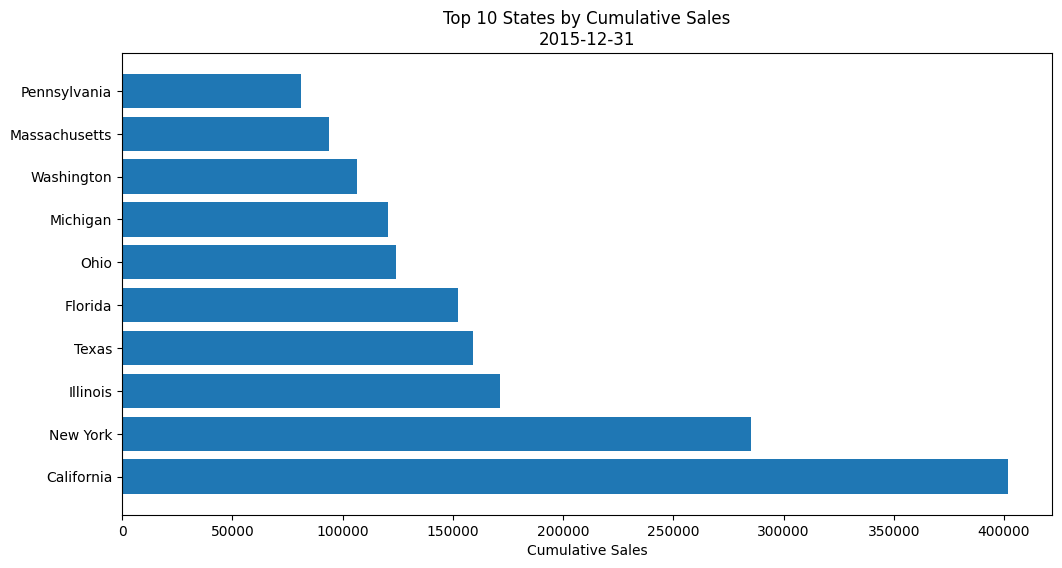

In [4]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(12, 6))

def animate(i):
    ax.clear()
    date = pivot_cumsum.index[i]
    data = pivot_cumsum.iloc[i].nlargest(10)
    
    ax.barh(data.index, data.values)
    ax.set_title(f'Top 10 States by Cumulative Sales\n{date}')
    ax.set_xlabel('Cumulative Sales')

ani = animation.FuncAnimation(
    fig, animate, 
    frames=len(pivot_cumsum),
    interval=100
)

ani.save('exports/top10_states_sales.gif', writer='pillow', fps=10)
plt.show()

In [5]:
# Učitaj podatke za Order Priority po sedmici
df_priority = pd.read_sql("""
    SELECT 
        c.week_number,
        c.year,
        o.order_priority,
        SUM(f.profit) as profit
    FROM fact_orders f
    JOIN dim_calendar c ON c.date_id = f.order_date_id
    JOIN dim_orderpriority o ON o.orderpriority_id = f.orderpriority_id
    GROUP BY c.year, c.week_number, o.order_priority
    ORDER BY c.year, c.week_number
""", engine)

# Dodaj year_week kolonu za sortiranje
df_priority['year_week'] = df_priority['year'].astype(str) + '-W' + df_priority['week_number'].astype(str).str.zfill(2)

# Pivot tabela
pivot_priority = df_priority.pivot_table(
    index='year_week',
    columns='order_priority',
    values='profit',
    aggfunc='sum'
).fillna(0)

# Kumulativna suma
pivot_priority_cumsum = pivot_priority.cumsum()

print(f"✅ Podaci učitani: {pivot_priority_cumsum.shape}")
print(pivot_priority_cumsum.head())

✅ Podaci učitani: (53, 5)
order_priority  Critical     High       Low   Medium  Not Specified
year_week                                                          
2015-W00         -607.47  1343.46  -1453.07  2595.07        -949.11
2015-W01       -12734.46  3142.79  -4558.58  -185.34        -278.93
2015-W02       -11161.46  1533.76  -4583.93  1571.26       -1686.12
2015-W03       -10310.38   764.82   3690.02  4391.42       -1340.11
2015-W04       -18149.67   303.16  14300.97  1883.99        2705.16


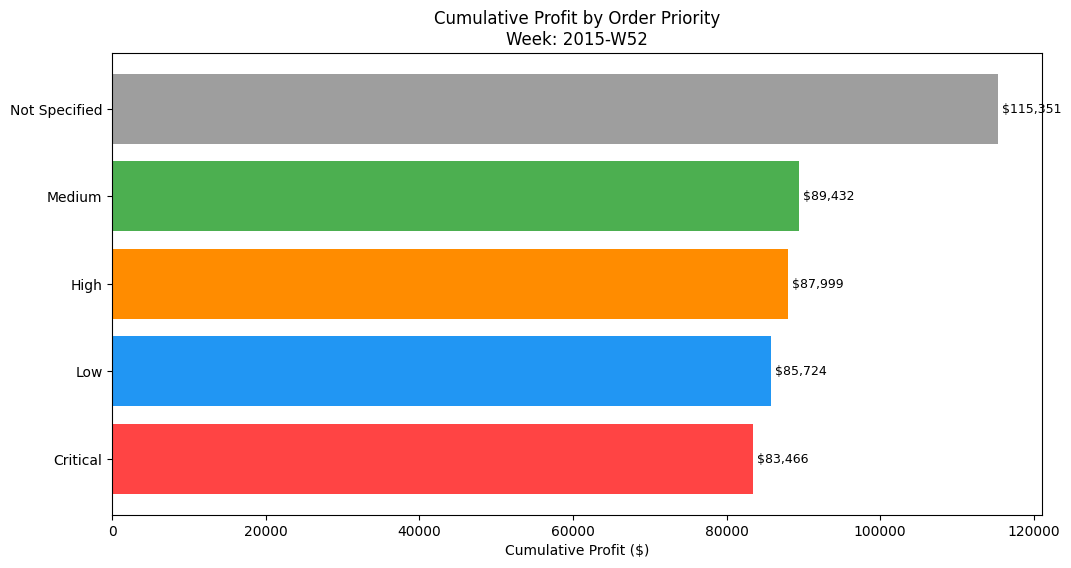

✅ GIF sačuvan!


In [6]:
fig2, ax2 = plt.subplots(figsize=(12, 6))

colors = {
    'Critical': '#FF4444',
    'High': '#FF8C00',
    'Medium': '#4CAF50',
    'Low': '#2196F3',
    'Not Specified': '#9E9E9E'
}

def animate_priority(i):
    ax2.clear()
    week = pivot_priority_cumsum.index[i]
    data = pivot_priority_cumsum.iloc[i].sort_values(ascending=True)
    
    bar_colors = [colors.get(p, '#9E9E9E') for p in data.index]
    
    ax2.barh(data.index, data.values, color=bar_colors)
    ax2.set_title(f'Cumulative Profit by Order Priority\nWeek: {week}')
    ax2.set_xlabel('Cumulative Profit ($)')
    
    for j, val in enumerate(data.values):
        ax2.text(val, j, f' ${val:,.0f}', va='center', fontsize=9)

ani_priority = animation.FuncAnimation(
    fig2, animate_priority,
    frames=len(pivot_priority_cumsum),
    interval=200
)

ani_priority.save('exports/priority_profit_race.gif', writer='pillow', fps=5)
plt.show()
print("✅ GIF sačuvan!")

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
from utils.db_connector import get_engine

engine = get_engine()
print("Imports uspešni!")

Konekcija kreirana: localhost/smart_store
Imports uspešni!


In [3]:
# Učitaj podatke iz MySQL sa svim potrebnim featurima
df = pd.read_sql("""
    SELECT 
        f.sales,
        f.discount,
        f.quantity,
        f.shipping_cost,
        f.unit_price,
        f.profit,
        p.product_category,
        p.product_sub_category,
        g.region,
        sm.ship_mode,
        op.order_priority
    FROM fact_orders f
    JOIN dim_product p ON p.product_key = f.product_id
    JOIN dim_geography g ON g.geography_id = f.geography_id
    JOIN dim_shipmode sm ON sm.shipmode_id = f.shipmode_id
    JOIN dim_orderpriority op ON op.orderpriority_id = f.orderpriority_id
""", engine)

print(f"Učitano {len(df)} redova")
print(f"\nKolone: {df.columns.tolist()}")
print(f"\nPrvih 5 redova:")
df.head()

Učitano 2851 redova

Kolone: ['sales', 'discount', 'quantity', 'shipping_cost', 'unit_price', 'profit', 'product_category', 'product_sub_category', 'region', 'ship_mode', 'order_priority']

Prvih 5 redova:


,sales,discount,quantity,shipping_cost,unit_price,profit,product_category,product_sub_category,region,ship_mode,order_priority
0,236.87,0.04,75,0.99,3.08,36.02,Office Supplies,Labels,Central,Regular Air,Critical
1,370.91,0.02,53,5.90,6.48,-50.64,Office Supplies,Paper,Central,Regular Air,Critical
2,4976.92,0.04,47,4.20,125.99,510.49,Technology,Telephones and Communication,Central,Regular Air,Critical
3,73.97,0.01,20,1.86,3.26,-4.67,Office Supplies,Pens & Art Supplies,South,Regular Air,Critical
4,232.50,0.05,35,8.73,6.48,-160.38,Office Supplies,Paper,South,Regular Air,Critical


In [4]:
# Encode kategoričke kolone u brojeve
le = LabelEncoder()
categorical_cols = ['product_category', 'product_sub_category', 
                    'region', 'ship_mode', 'order_priority']

df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Features i target
X = df_encoded.drop('profit', axis=1)
y = df_encoded['profit']

print(f"Features: {X.columns.tolist()}")
print(f"Target: profit")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train/Test split — 80% trening, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n Train size: {len(X_train)} redova")
print(f" Test size:  {len(X_test)} redova")

Features: ['sales', 'discount', 'quantity', 'shipping_cost', 'unit_price', 'product_category', 'product_sub_category', 'region', 'ship_mode', 'order_priority']
Target: profit
X shape: (2851, 10)
y shape: (2851,)

 Train size: 2280 redova
 Test size:  571 redova


In [7]:
# Kreiraj i treniraj Random Forest model
print("Treniram model...")

model = RandomForestRegressor(
    n_estimators=100,   # broj stabala u šumi
    max_depth=10,       # maksimalna dubina stabla
    random_state=42     # reproduktibilnost rezultata
)

model.fit(X_train, y_train)
print("Model istreniran!")

# Predikcija na test setu
y_pred = model.predict(X_test)

# Evaluacija
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\nRezultati modela:")
print(f"MAE  (Mean Absolute Error): ${mae:.2f}")
print(f"RMSE (Root Mean Sq. Error): ${rmse:.2f}")
print(f"R2   Score:                 {r2:.3f}")

Treniram model...
Model istreniran!

Rezultati modela:
MAE  (Mean Absolute Error): $266.65
RMSE (Root Mean Sq. Error): $838.95
R2   Score:                 0.271


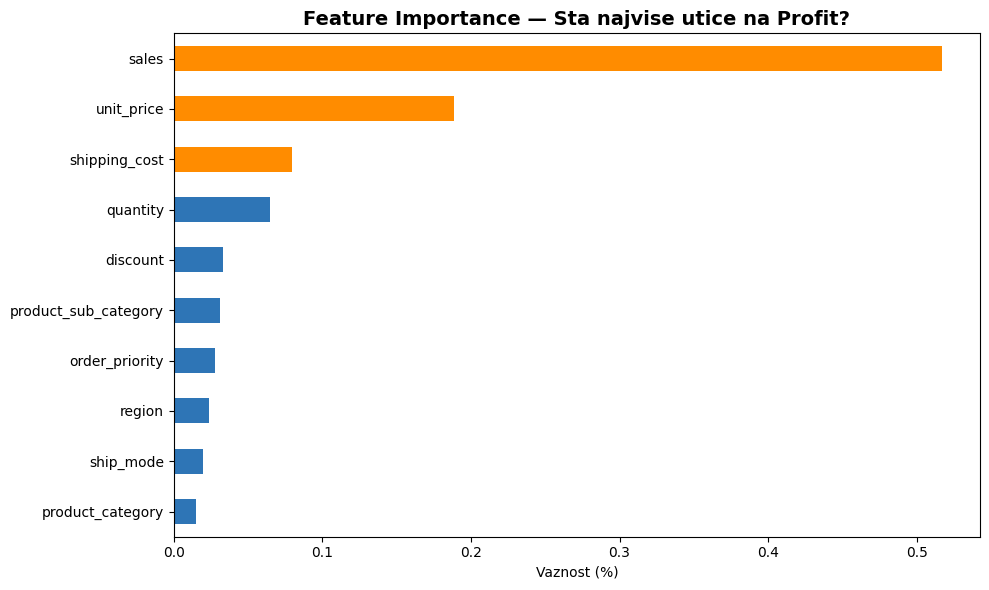

Feature Importance sačuvan!

Top 3 najvaznije features:
shipping_cost    0.079587
unit_price       0.188337
sales            0.516757
dtype: float64


In [9]:
# Feature Importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2E75B6' if i < len(importance)-3 
          else '#FF8C00' for i in range(len(importance))]
importance.plot(kind='barh', color=colors)
plt.title('Feature Importance — Sta najvise utice na Profit?',
          fontsize=14, fontweight='bold')
plt.xlabel('Vaznost (%)')
plt.tight_layout()
plt.savefig('exports/feature_importance.png', dpi=150)
plt.show()
print("Feature Importance sačuvan!")
print("\nTop 3 najvaznije features:")
print(importance.tail(3))

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
from utils.db_connector import get_engine

engine = get_engine()

# Učitaj Sales po regionima
df_anova = pd.read_sql("""
    SELECT 
        g.region,
        f.sales
    FROM fact_orders f
    JOIN dim_geography g ON g.geography_id = f.geography_id
""", engine)

print(f"Učitano {len(df_anova)} redova")
print(f"\nBroj redova po regionu:")
print(df_anova['region'].value_counts())
print(f"\nProsečni Sales po regionu:")
print(df_anova.groupby('region')['sales'].mean().round(2))

Konekcija kreirana: localhost/smart_store
Učitano 2851 redova

Broj redova po regionu:
region
Central    853
East       686
West       679
South      633
Name: count, dtype: int64

Prosečni Sales po regionu:
region
Central     946.21
East       1298.93
South       920.75
West       1204.78
Name: sales, dtype: float64


Shapiro-Wilk test normalnosti:
(p > 0.05 = normalna distribucija)

West       → p=0.0000  Nije normalna
East       → p=0.0043  Nije normalna
South      → p=0.0000  Nije normalna
Central    → p=0.0000  Nije normalna


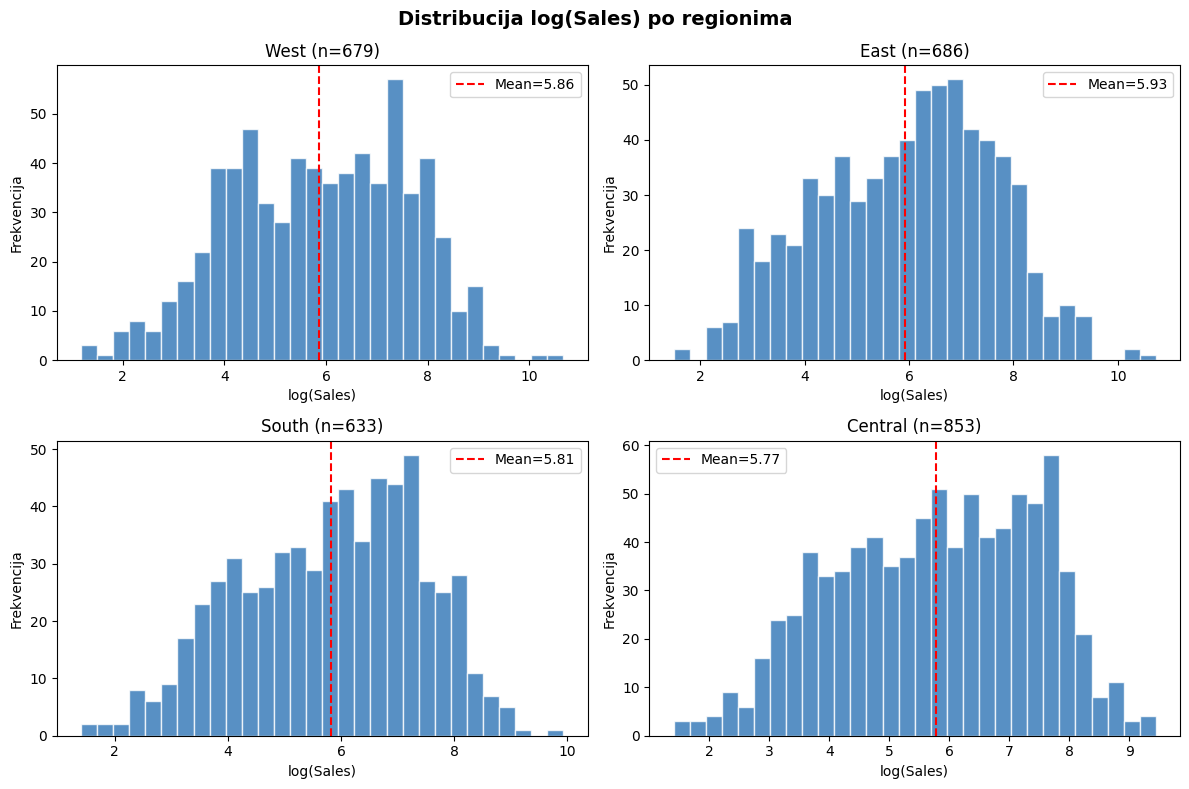

 Vizualizacija sacuvana!


In [3]:
# Log transformacija — ANOVA zahteva normalnu distribuciju
df_anova['log_sales'] = np.log1p(df_anova['sales'])

# Podeli po regionima
west    = df_anova[df_anova['region'] == 'West']['log_sales']
east    = df_anova[df_anova['region'] == 'East']['log_sales']
south   = df_anova[df_anova['region'] == 'South']['log_sales']
central = df_anova[df_anova['region'] == 'Central']['log_sales']

# Shapiro-Wilk test normalnosti za svaki region
print("Shapiro-Wilk test normalnosti:")
print("(p > 0.05 = normalna distribucija)\n")
for name, data in [('West', west), ('East', east), 
                    ('South', south), ('Central', central)]:
    stat, p = stats.shapiro(data.sample(min(500, len(data)), 
                             random_state=42))
    status = ' Normalna' if p > 0.05 else ' Nije normalna'
    print(f"{name:10} → p={p:.4f} {status}")

# Vizualizacija distribucija
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribucija log(Sales) po regionima', 
             fontsize=14, fontweight='bold')

for ax, (name, data) in zip(axes.flatten(), 
    [('West', west), ('East', east), 
     ('South', south), ('Central', central)]):
    ax.hist(data, bins=30, color='#2E75B6', 
            edgecolor='white', alpha=0.8)
    ax.set_title(f'{name} (n={len(data)})')
    ax.set_xlabel('log(Sales)')
    ax.set_ylabel('Frekvencija')
    ax.axvline(data.mean(), color='red', 
               linestyle='--', label=f'Mean={data.mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig('exports/anova_distribucije.png', dpi=150)
plt.show()
print(" Vizualizacija sacuvana!")

In [4]:
# Kruskal-Wallis test — neparametarska alternativa ANOVA
# Ne zahteva normalnu distribuciju!
stat, p_value = stats.kruskal(west, east, south, central)

print("=" * 50)
print(" KRUSKAL-WALLIS TEST")
print("=" * 50)
print(f"Test statistika: {stat:.4f}")
print(f"p-value:         {p_value:.6f}")
print()

if p_value < 0.05:
    print(" p < 0.05 — Odbacujemo H0!")
    print("Postoji statistički značajna razlika")
    print("između regiona u Sales vrednostima.")
else:
    print(" p > 0.05 — Ne možemo odbaciti H0")
    print("Nema statistički značajne razlike.")

print()
print("Opisna statistika po regionu:")
print(df_anova.groupby('region')['sales'].agg([
    'count', 'mean', 'median', 'std'
]).round(2))

 KRUSKAL-WALLIS TEST
Test statistika: 3.1933
p-value:         0.362772

 p > 0.05 — Ne možemo odbaciti H0
Nema statistički značajne razlike.

Opisna statistika po regionu:
         count     mean  median      std
region                                  
Central    853   946.21  356.14  1456.64
East       686  1298.93  458.48  2995.08
South      633   920.75  391.40  1484.74
West       679  1204.78  378.23  2559.53


C:\Users\bogdan.stankovic\AppData\Local\Temp\ipykernel_5492\2720664045.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_region, labels=regions,


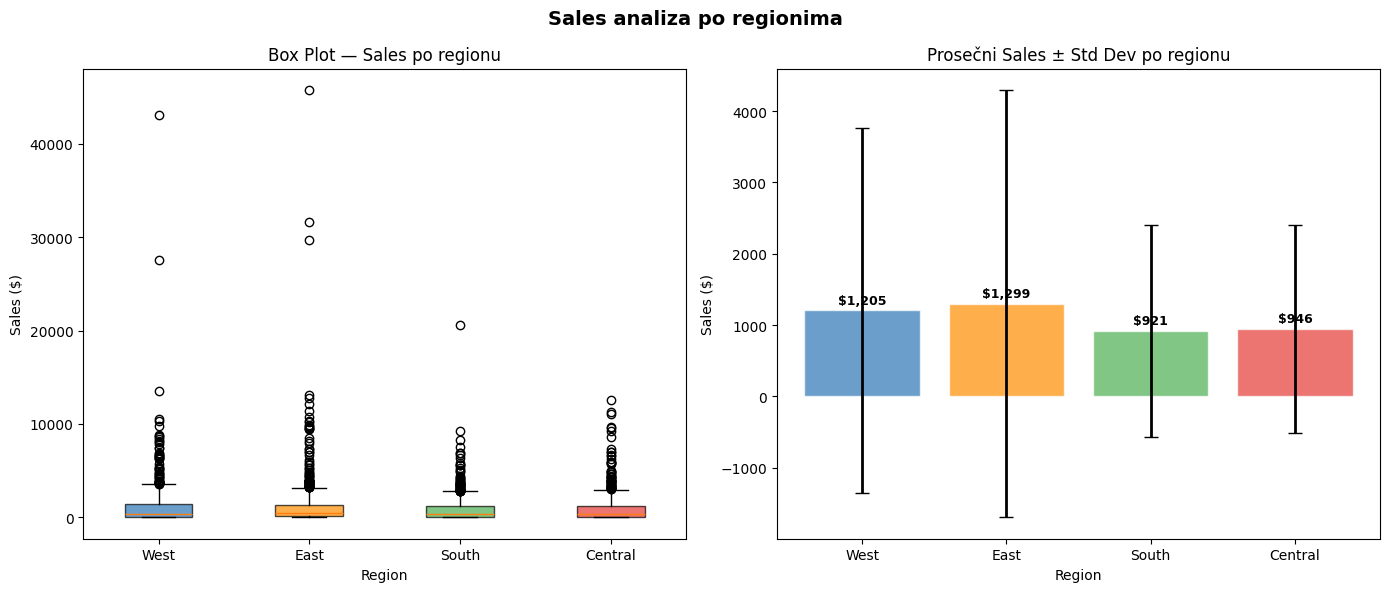

 Vizualizacija sacuvana!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sales analiza po regionima', 
             fontsize=14, fontweight='bold')

# Box plot
regions = ['West', 'East', 'South', 'Central']
data_by_region = [
    df_anova[df_anova['region'] == r]['sales'] 
    for r in regions
]

colors = ['#2E75B6', '#FF8C00', '#4CAF50', '#E53935']

bp = axes[0].boxplot(data_by_region, labels=regions,
                      patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Box Plot — Sales po regionu')
axes[0].set_ylabel('Sales ($)')
axes[0].set_xlabel('Region')

# Bar chart sa error bars
means = [df_anova[df_anova['region']==r]['sales'].mean() 
         for r in regions]
stds  = [df_anova[df_anova['region']==r]['sales'].std() 
         for r in regions]

bars = axes[1].bar(regions, means, color=colors, 
                    alpha=0.7, edgecolor='white')
axes[1].errorbar(regions, means, yerr=stds, 
                  fmt='none', color='black', 
                  capsize=5, linewidth=2)
axes[1].set_title('Prosečni Sales ± Std Dev po regionu')
axes[1].set_ylabel('Sales ($)')
axes[1].set_xlabel('Region')

# Dodaj vrednosti na barove
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                  bar.get_height() + 50,
                  f'${mean:,.0f}', 
                  ha='center', va='bottom', 
                  fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('exports/anova_rezultati.png', dpi=150)
plt.show()
print(" Vizualizacija sacuvana!")

In [7]:

df_original = pd.read_sql("""
    SELECT 
        g.region,
        f.sales
    FROM fact_orders f
    JOIN dim_geography g ON g.geography_id = f.geography_id
    JOIN dim_calendar c ON c.date_id = f.order_date_id
    WHERE f.row_id <= 26389
    AND c.month_number <= 6
""", engine)

print(f"✅ Učitano {len(df_original)} redova")
print(f"\nBroj redova po regionu:")
print(df_original['region'].value_counts())
print(f"\nProsečni Sales po regionu:")
print(df_original.groupby('region')['sales'].mean().round(2))

✅ Učitano 1951 redova

Broj redova po regionu:
region
Central    566
East       474
West       470
South      441
Name: count, dtype: int64

Prosečni Sales po regionu:
region
Central     792.02
East       1249.31
South       801.60
West       1120.80
Name: sales, dtype: float64


In [8]:
# Log transformacija
df_original['log_sales'] = np.log1p(df_original['sales'])

# Podeli po regionima
west    = df_original[df_original['region'] == 'West']['log_sales']
east    = df_original[df_original['region'] == 'East']['log_sales']
south   = df_original[df_original['region'] == 'South']['log_sales']
central = df_original[df_original['region'] == 'Central']['log_sales']

# Shapiro-Wilk test
print("📊 Shapiro-Wilk test normalnosti:")
print("(p > 0.05 = normalna distribucija)\n")
for name, data in [('West', west), ('East', east),
                    ('South', south), ('Central', central)]:
    stat, p = stats.shapiro(data.sample(
        min(500, len(data)), random_state=42))
    status = '✅ Normalna' if p > 0.05 else '⚠️ Nije normalna'
    print(f"{name:10} → p={p:.4f} {status}")

📊 Shapiro-Wilk test normalnosti:
(p > 0.05 = normalna distribucija)

West       → p=0.0001 ⚠️ Nije normalna
East       → p=0.0001 ⚠️ Nije normalna
South      → p=0.0044 ⚠️ Nije normalna
Central    → p=0.0003 ⚠️ Nije normalna


In [9]:
stat, p_value = stats.kruskal(west, east, south, central)

print("=" * 50)
print("📊 KRUSKAL-WALLIS TEST — Originalni podaci H1")
print("=" * 50)
print(f"Test statistika: {stat:.4f}")
print(f"p-value:         {p_value:.6f}")
print()

if p_value < 0.05:
    print("✅ p < 0.05 — Odbacujemo H0!")
    print("Postoji statistički značajna razlika!")
else:
    print("❌ p > 0.05 — Ne možemo odbaciti H0")
    print("Nema statistički značajne razlike.")

print("\nOpisna statistika:")
print(df_original.groupby('region')['sales'].agg([
    'count', 'mean', 'median', 'std'
]).round(2))

📊 KRUSKAL-WALLIS TEST — Originalni podaci H1
Test statistika: 2.7745
p-value:         0.427719

❌ p > 0.05 — Ne možemo odbaciti H0
Nema statistički značajne razlike.

Opisna statistika:
         count     mean  median      std
region                                  
Central    566   792.02  188.58  1610.02
East       474  1249.31  228.40  3524.72
South      441   801.60  220.52  1639.50
West       470  1120.80  193.14  2984.27
